In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [19]:
df = pd.read_csv("pokemon_competitive_clean.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  1303 non-null   int64  
 1   name                   1303 non-null   object 
 2   type1                  1303 non-null   object 
 3   type2                  1303 non-null   object 
 4   ability1               1303 non-null   object 
 5   ability2               1303 non-null   object 
 6   hidden_ability         1303 non-null   object 
 7   hp                     1303 non-null   int64  
 8   attack                 1303 non-null   int64  
 9   defense                1303 non-null   int64  
 10  sp_atk                 1303 non-null   int64  
 11  sp_def                 1303 non-null   int64  
 12  speed                  1303 non-null   int64  
 13  total_stats            1303 non-null   int64  
 14  legendary              1303 non-null   bool   
 15  myth

,index,hp,attack,defense,sp_atk,sp_def,speed,total_stats,smogon_vgc_usage_2022,smogon_vgc_usage_2023,smogon_vgc_usage_2024,worlds_vgc_usage_2022,worlds_vgc_usage_2023,worlds_vgc_usage_2024,avg_smogon_usage,avg_worlds_usage,avg_total_usage,high_usage
count,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000
mean,507.049117,71.345357,81.589409,75.236378,73.682272,72.973906,71.132003,445.959325,0.467084,0.861141,0.545187,0.455610,0.450814,0.442464,0.624471,0.449629,0.537050,0.250192
std,305.094864,26.881097,31.665341,30.481507,32.487035,27.348706,30.311710,119.953360,3.417102,4.155596,3.212637,3.561326,3.319312,2.757801,2.745733,2.233308,2.393311,0.433290
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,234.500000,54.000000,58.000000,53.000000,50.000000,52.000000,47.500000,335.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,511.000000,70.000000,80.000000,70.000000,65.000000,70.000000,70.000000,470.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,774.000000,85.000000,100.000000,95.000000,95.000000,90.000000,92.000000,525.000000,0.000015,0.001370,0.008655,0.000000,0.000000,0.000000,0.027412,0.013333,0.022523,0.500000
max,1025.000000,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000,1125.000000,60.391720,48.975560,59.437100,73.410000,51.320000,38.210000,35.900473,35.270000,33.533460,1.000000


In [20]:
df.isna().sum().sort_values(ascending=False)

index                    0
legendary                0
avg_total_usage          0
avg_worlds_usage         0
avg_smogon_usage         0
worlds_vgc_usage_2024    0
worlds_vgc_usage_2023    0
worlds_vgc_usage_2022    0
smogon_vgc_usage_2024    0
smogon_vgc_usage_2023    0
smogon_vgc_usage_2022    0
generation               0
mythical                 0
total_stats              0
name                     0
speed                    0
sp_def                   0
sp_atk                   0
defense                  0
attack                   0
hp                       0
hidden_ability           0
ability2                 0
ability1                 0
type2                    0
type1                    0
high_usage               0
dtype: int64

## Objective

The goal of this analysis is to understand which characteristics (stats, types, etc.) are associated with higher competitive usage in Pokémon tournaments.

This analysis uses the cleaned dataset prepared in the data cleaning stage to ensure consistency and reliability.

usage_cols = [col for col in df.columns if "usage" in col]
print(usage_cols)

In [21]:
df.sort_values("avg_total_usage", ascending=False)[["name", "avg_total_usage"]].head(10)

,name,avg_total_usage
909,incineroar,33.533460
1250,flutter-mane,26.481903
1030,rillaboom,24.901868
743,amoonguss,21.195163
1131,zacian-crowned,19.573418
795,tornadus-incarnate,19.045093
1138,urshifu-rapid,18.766402
802,landorus-therian,18.231670
1255,iron-hands,16.467563
498,kyogre,15.891417


## Top Competitive Pokémon

This gives a quick overview of the most used Pokémon in competitive environments.

In [22]:
stat_cols = ["hp", "attack", "defense", "sp_atk", "sp_def", "speed", "total_stats"]

correlations = df[stat_cols + ["avg_total_usage"]].corr()["avg_total_usage"].sort_values(ascending=False)

correlations

avg_total_usage    1.000000
total_stats        0.207306
hp                 0.171127
attack             0.156991
sp_atk             0.143590
sp_def             0.131274
speed              0.129399
defense            0.102308
Name: avg_total_usage, dtype: float64

## Stat Importance

We analyze how each stat correlates with competitive usage to understand which attributes contribute most to a Pokémon’s success.

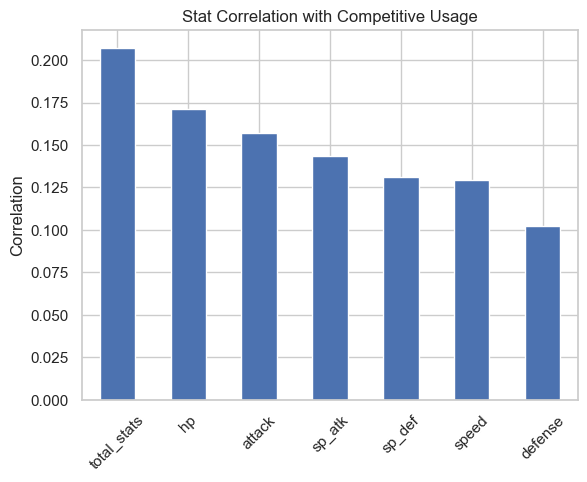

In [23]:
correlations.drop("avg_total_usage").plot(kind="bar")
plt.title("Stat Correlation with Competitive Usage")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

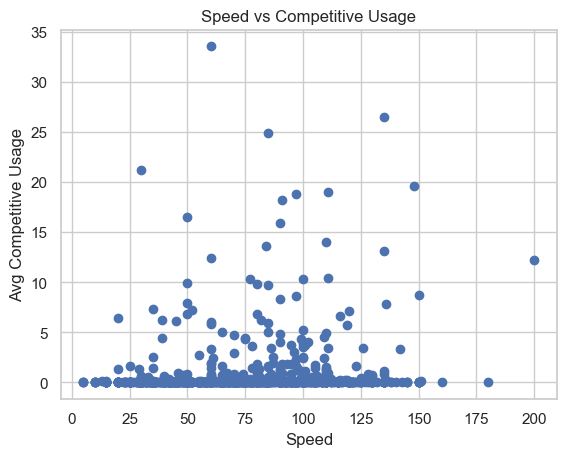

In [24]:
plt.scatter(df["speed"], df["avg_total_usage"])
plt.xlabel("Speed")
plt.ylabel("Avg Competitive Usage")
plt.title("Speed vs Competitive Usage")
plt.show()

## Speed Analysis

Speed is often considered one of the most important stats in competitive Pokémon.

This plot helps visualize whether faster Pokémon tend to be used more frequently.

In [25]:
df.groupby("type1")["avg_total_usage"].mean().sort_values(ascending=False).head(10)

type1
flying      1.608191
dark        1.117632
fighting    1.058952
fire        1.011927
ground      1.003371
grass       0.838576
fairy       0.827354
dragon      0.750252
ghost       0.638152
psychic     0.530886
Name: avg_total_usage, dtype: float64

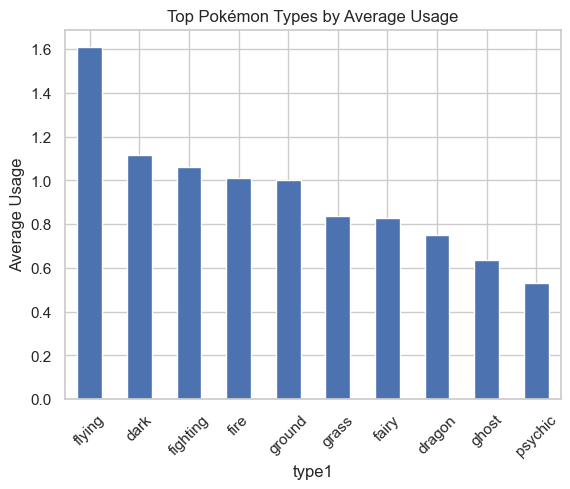

In [26]:
top_types = df.groupby("type1")["avg_total_usage"].mean().sort_values(ascending=False).head(10)

top_types.plot(kind="bar")
plt.title("Top Pokémon Types by Average Usage")
plt.ylabel("Average Usage")
plt.xticks(rotation=45)
plt.show()

In [27]:
df.groupby("legendary")["avg_total_usage"].mean()

legendary
False    0.367909
True     2.251587
Name: avg_total_usage, dtype: float64

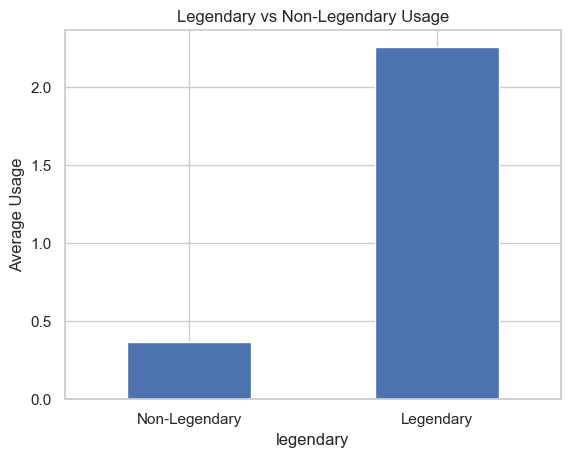

In [28]:
df.groupby("legendary")["avg_total_usage"].mean().plot(kind="bar")
plt.title("Legendary vs Non-Legendary Usage")
plt.ylabel("Average Usage")
plt.xticks([0,1], ["Non-Legendary", "Legendary"], rotation=0)
plt.show()

In [29]:
print(df.columns.tolist())

['index', 'name', 'type1', 'type2', 'ability1', 'ability2', 'hidden_ability', 'hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed', 'total_stats', 'legendary', 'mythical', 'generation', 'smogon_vgc_usage_2022', 'smogon_vgc_usage_2023', 'smogon_vgc_usage_2024', 'worlds_vgc_usage_2022', 'worlds_vgc_usage_2023', 'worlds_vgc_usage_2024', 'avg_smogon_usage', 'avg_worlds_usage', 'avg_total_usage', 'high_usage']


In [30]:
usage_cols = [col for col in df.columns if "usage" in col]
print(usage_cols)

df[usage_cols].head(10)

['smogon_vgc_usage_2022', 'smogon_vgc_usage_2023', 'smogon_vgc_usage_2024', 'worlds_vgc_usage_2022', 'worlds_vgc_usage_2023', 'worlds_vgc_usage_2024', 'avg_smogon_usage', 'avg_worlds_usage', 'avg_total_usage', 'high_usage']


,smogon_vgc_usage_2022,smogon_vgc_usage_2023,smogon_vgc_usage_2024,worlds_vgc_usage_2022,worlds_vgc_usage_2023,worlds_vgc_usage_2024,avg_smogon_usage,avg_worlds_usage,avg_total_usage,high_usage
0,0.00000,0.00000,0.00000,0.00,0.0,0.00,0.000000,0.000000,0.000000,0
1,0.00000,0.00000,0.00000,0.00,0.0,0.00,0.000000,0.000000,0.000000,0
2,20.83915,0.00000,0.44410,19.62,0.0,0.09,7.094417,6.570000,6.832208,1
3,0.00000,0.00000,0.00000,0.00,0.0,0.00,0.000000,0.000000,0.000000,0
4,0.00000,0.00000,0.00000,0.00,0.0,0.00,0.000000,0.000000,0.000000,0
5,0.00000,0.00000,0.00000,0.00,0.0,0.00,0.000000,0.000000,0.000000,0
6,0.00000,0.00000,0.00000,0.00,0.0,0.00,0.000000,0.000000,0.000000,0
7,7.17374,0.44681,0.04722,20.53,0.0,3.19,2.555923,7.906667,5.231295,1
8,0.00000,0.00000,0.00000,0.00,0.0,0.00,0.000000,0.000000,0.000000,0
9,0.00000,0.00000,0.00000,0.00,0.0,0.00,0.000000,0.000000,0.000000,0


In [31]:
df[usage_cols].isna().sum()

smogon_vgc_usage_2022    0
smogon_vgc_usage_2023    0
smogon_vgc_usage_2024    0
worlds_vgc_usage_2022    0
worlds_vgc_usage_2023    0
worlds_vgc_usage_2024    0
avg_smogon_usage         0
avg_worlds_usage         0
avg_total_usage          0
high_usage               0
dtype: int64

In [32]:
df[usage_cols].dtypes

smogon_vgc_usage_2022    float64
smogon_vgc_usage_2023    float64
smogon_vgc_usage_2024    float64
worlds_vgc_usage_2022    float64
worlds_vgc_usage_2023    float64
worlds_vgc_usage_2024    float64
avg_smogon_usage         float64
avg_worlds_usage         float64
avg_total_usage          float64
high_usage                 int64
dtype: object

## Key EDA Insights

- **Total stats is the strongest predictor** of competitive usage (r = 0.21), suggesting overall stat budget matters more than any individual stat
- **Legendary Pokémon are used ~6x more** on average (2.25 vs 0.37 avg usage), making legendary status a dominant categorical signal
- **HP is the most relevant individual stat** (r = 0.17), pointing to survivability — bulky support roles (Amoonguss, Incineroar) dominate usage
- **Speed is one of the weakest predictors** (r = 0.13), challenging the common assumption that faster Pokémon dominate VGC
- **All individual correlations are weak** (max 0.21), confirming no single stat explains competitive success — combined features and role are necessary
- **Flying and Dark types lead by average usage**, driven by meta staples like Tornadus and Incineroar — type can proxy for role

## 🔗 How EDA Informs Modeling

The EDA highlights that no single stat strongly predicts competitive usage, with all correlations remaining relatively weak. This suggests that:

- Composite features (e.g. total stats, bulk, offense) are likely more predictive than individual stats
- Non-linear relationships may exist between variables (e.g. combinations of speed and bulk)
- Categorical features such as legendary status and typing play a significant role

These insights motivated:
- The creation of engineered features (offense_score, bulk_score, etc.)
- The use of ensemble models (Random Forest, Gradient Boosting) capable of capturing non-linear interactions